In [70]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np


In [18]:

digits = load_digits()
X, y = digits.data, digits.target

print(X.shape[0])          # 1797 images
print(X.shape[1])          # 64 pixels each (8x8)
print(list(range(10)))     # classes 0..9

# draw one image as text (bright pixels = #)
for row in digits.images[2]:
    print("".join("#" if v > 6 else " " for v in row))

1797
64
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ##  
   ###  
  ####  
    ##  
  ###   
 ###    
  ####  
    ### 


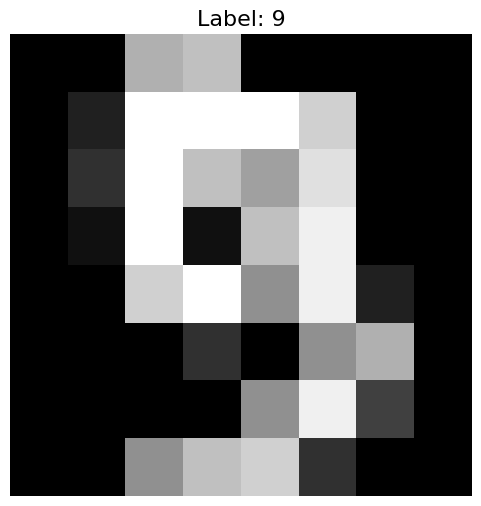

In [38]:
index = 9

# Increase figure size
plt.figure(figsize=(6, 6))  # Width, Height in inches

# Display the image
plt.imshow(digits.images[index], cmap="gray")
plt.title(f"Label: {digits.target[index]}", fontsize=16)
plt.axis("off")
plt.show()

In [48]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

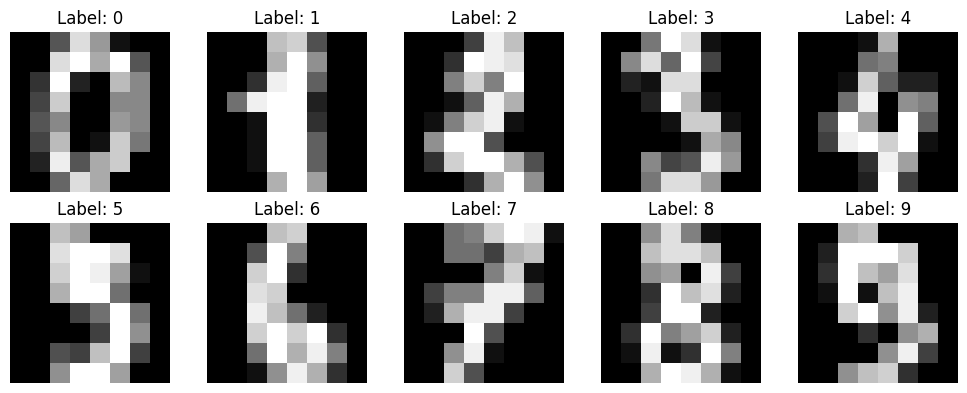

In [46]:


digits = load_digits()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [81]:


X, y = load_digits(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_tr, y_tr)
net  = make_pipeline(StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(80,),early_stopping=True, max_iter=1000, random_state=42)).fit(X_tr, y_tr)


base_pred = base.predict(X_te)
net_pred = net.predict(X_te)

print(base.score(X_te, y_te))     # 0.978  baseline
print(net.score(X_te,  y_te)) 

0.9777777777777777
0.9622222222222222


/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/kbshal/mero

In [80]:
for i in np.arange(10):
    print(f"{i} count is {len(y_te[y_te==i])}")

0 count is 45
1 count is 46
2 count is 44
3 count is 46
4 count is 45
5 count is 46
6 count is 45
7 count is 45
8 count is 43
9 count is 45


In [63]:
matrix = confusion_matrix(y_te, base_pred )
matrix

array([[45,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 43,  0,  0,  1,  0,  0,  0,  2,  0],
       [ 0,  0, 44,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 46,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 45,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 45,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  0, 44,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 45,  0,  0],
       [ 0,  3,  0,  0,  0,  0,  0,  0, 40,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  1, 43]])

# How big a network?

In [25]:
X, y = load_digits(return_X_y=True)
for size in [(16,), (64,), (128,), (64, 64)]:
    net = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=size, max_iter=1000, random_state=42))
    
    print(size, cross_val_score(net, X, y, cv=5).mean())

/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered 

(16,) 0.9232048901268957


/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered 

(64,) 0.9359996904982978


/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered 

(128,) 0.9293268337975858


/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered 

(64, 64) 0.9343252862890745


/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Cross-validate hidden sizes (16,), (64,), (128,), (64, 64).
Which scores best? Is bigger always better?
Write one sentence: which network would you ship, and why?